In [15]:
!pip install ultralytics shap xgboost scikit-learn opencv-python-headless -q

import cv2
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from ultralytics import YOLO
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from IPython.display import display, Image

In [16]:
model = YOLO("yolov8m.pt")

VEHICLE_CLASSES = {
    2: "car", 3: "motorcycle", 5: "bus", 7: "truck"
}

print("Model loaded. Vehicle classes we track:", VEHICLE_CLASSES)

Model loaded. Vehicle classes we track: {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}


In [17]:
def extract_frame_features(frame, model, img_area):
    results = model(frame, conf=0.25, verbose=False)[0]
    boxes = results.boxes

    vehicle_count = 0
    confidences = []
    areas = []
    centers = []

    for box in boxes:
        cls_id = int(box.cls)
        if cls_id not in VEHICLE_CLASSES:
            continue

        vehicle_count += 1
        confidences.append(float(box.conf))

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        box_area = (x2 - x1) * (y2 - y1)
        areas.append(box_area)
        centers.append(((x1 + x2) / 2, (y1 + y2) / 2))

    feat_count = vehicle_count
    feat_avg_conf = np.mean(confidences) if confidences else 0.0
    feat_density = sum(areas) / img_area if areas else 0.0

    if len(centers) >= 2:
        dists = []
        for i in range(len(centers)):
            for j in range(i + 1, len(centers)):
                d = np.sqrt((centers[i][0]-centers[j][0])**2 +
                            (centers[i][1]-centers[j][1])**2)
                dists.append(d)
        feat_proximity = 1 / (np.mean(dists) + 1e-5)
    else:
        feat_proximity = 0.0

    large_classes = {5, 7}
    large_count = sum(1 for box in boxes if int(box.cls) in large_classes)
    feat_large_ratio = large_count / (vehicle_count + 1e-5)

    return {
        "vehicle_count": feat_count,
        "avg_confidence": feat_avg_conf,
        "density_score": feat_density,
        "proximity_score": feat_proximity,
        "large_vehicle_ratio": feat_large_ratio
    }

In [19]:
from google.colab import files
uploaded = files.upload()  # this opens a file picker — choose your video
video_path = list(uploaded.keys())[0]
print(f"Uploaded: {video_path}")

Saving vidssave.com Road traffic video for object recognition 360P.mp4 to vidssave.com Road traffic video for object recognition 360P (1).mp4
Uploaded: vidssave.com Road traffic video for object recognition 360P (1).mp4


Total boxes detected: 14
Class ID: 7 (truck), confidence: 0.94
Class ID: 2 (car), confidence: 0.89
Class ID: 7 (truck), confidence: 0.86
Class ID: 2 (car), confidence: 0.85
Class ID: 2 (car), confidence: 0.80
Class ID: 2 (car), confidence: 0.79
Class ID: 7 (truck), confidence: 0.70
Class ID: 2 (car), confidence: 0.64
Class ID: 2 (car), confidence: 0.62
Class ID: 2 (car), confidence: 0.56
Class ID: 2 (car), confidence: 0.44
Class ID: 2 (car), confidence: 0.36
Class ID: 2 (car), confidence: 0.34
Class ID: 2 (car), confidence: 0.33


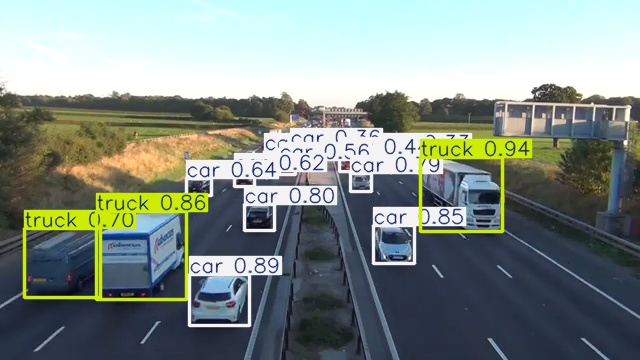

In [20]:
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 50)
ret, frame = cap.read()
cap.release()

results = model(frame, conf=0.25, verbose=False)[0]
print("Total boxes detected:", len(results.boxes))
for box in results.boxes:
    cls_id = int(box.cls)
    conf = float(box.conf)
    print(f"Class ID: {cls_id} ({model.names[cls_id]}), confidence: {conf:.2f}")

annotated = results.plot()
cv2.imwrite("sanity_check.jpg", annotated)
display(Image("sanity_check.jpg"))

In [21]:
cap = cv2.VideoCapture(video_path)

img_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
img_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
img_area = img_w * img_h
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

records = []
frame_idx = 0
SAMPLE_EVERY = 5

print(f"Video: {img_w}x{img_h}, {total_frames} frames total")
print(f"Processing every {SAMPLE_EVERY}th frame...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    if frame_idx % SAMPLE_EVERY == 0:
        feats = extract_frame_features(frame, model, img_area)
        feats["frame_idx"] = frame_idx
        records.append(feats)
    frame_idx += 1

cap.release()
df = pd.DataFrame(records)
print(f"\nExtracted features from {len(df)} frames")
print(df.describe())

Video: 640x360, 51201 frames total
Processing every 5th frame...

Extracted features from 10241 frames
       vehicle_count  avg_confidence  density_score  proximity_score  \
count   10241.000000    10241.000000   10241.000000     10241.000000   
mean       14.311395        0.627775       0.078717         0.007607   
std         2.637729        0.056486       0.045135         0.028487   
min         0.000000        0.000000       0.000000         0.000000   
25%        13.000000        0.601652       0.048747         0.006381   
50%        14.000000        0.629847       0.067874         0.007104   
75%        16.000000        0.657906       0.095965         0.008040   
max        26.000000        0.802322       0.393622         2.886316   

       large_vehicle_ratio     frame_idx  
count         10241.000000  10241.000000  
mean              0.126677  25600.000000  
std               0.091635  14782.331937  
min               0.000000      0.000000  
25%               0.066667  12800

In [23]:
# Cell 6 — Data-driven labeling using percentiles
# Instead of guessing fixed numbers, we derive thresholds from this video's
# own distribution of vehicle_count. This adapts to whatever traffic density
# the actual footage shows, rather than assuming numbers that don't fit.

p33 = df["vehicle_count"].quantile(0.33)
p66 = df["vehicle_count"].quantile(0.66)

print(f"33rd percentile vehicle_count: {p33}")
print(f"66th percentile vehicle_count: {p66}")

def assign_label(row, low_thresh, high_thresh):
    if row["vehicle_count"] <= low_thresh:
        return "normal"
    elif row["vehicle_count"] <= high_thresh:
        return "congested"
    else:
        return "high_risk"

df["label"] = df.apply(lambda row: assign_label(row, p33, p66), axis=1)

print("\nLabel distribution:")
print(df["label"].value_counts())
df[["vehicle_count", "density_score", "proximity_score", "label"]].head(10)

33rd percentile vehicle_count: 13.0
66th percentile vehicle_count: 15.0

Label distribution:
label
normal       3752
high_risk    3299
congested    3190
Name: count, dtype: int64


,vehicle_count,density_score,proximity_score,label
0,15,0.052640,0.006758,congested
1,15,0.064827,0.006504,congested
2,12,0.065539,0.005532,normal
3,12,0.061623,0.006522,normal
4,13,0.069168,0.006670,normal
5,12,0.064405,0.007915,normal
6,12,0.082586,0.008165,normal
7,14,0.105362,0.007556,congested
8,14,0.121062,0.006560,congested
9,16,0.167802,0.006818,high_risk


In [25]:
# Cell 7 — Train using features that DON'T leak the label
feature_cols = ["avg_confidence", "density_score",
                "proximity_score", "large_vehicle_ratio"]  # vehicle_count removed

le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])

X = df[feature_cols]
y = df["label_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="mlogloss",
    random_state=42
)

clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

   congested       0.92      0.92      0.92       638
   high_risk       0.94      0.94      0.94       660
      normal       0.94      0.95      0.94       751

    accuracy                           0.94      2049
   macro avg       0.94      0.93      0.93      2049
weighted avg       0.94      0.94      0.94      2049



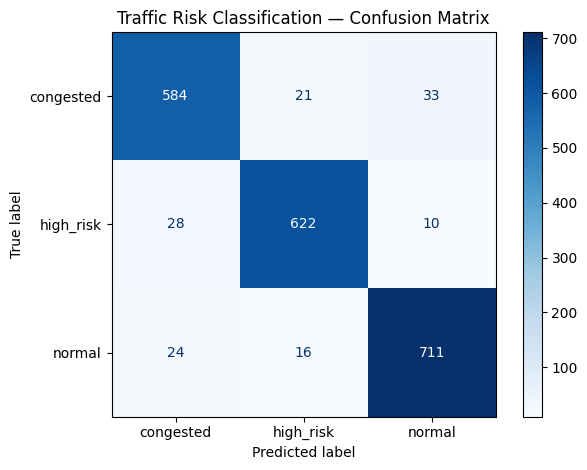

In [26]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Traffic Risk Classification — Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

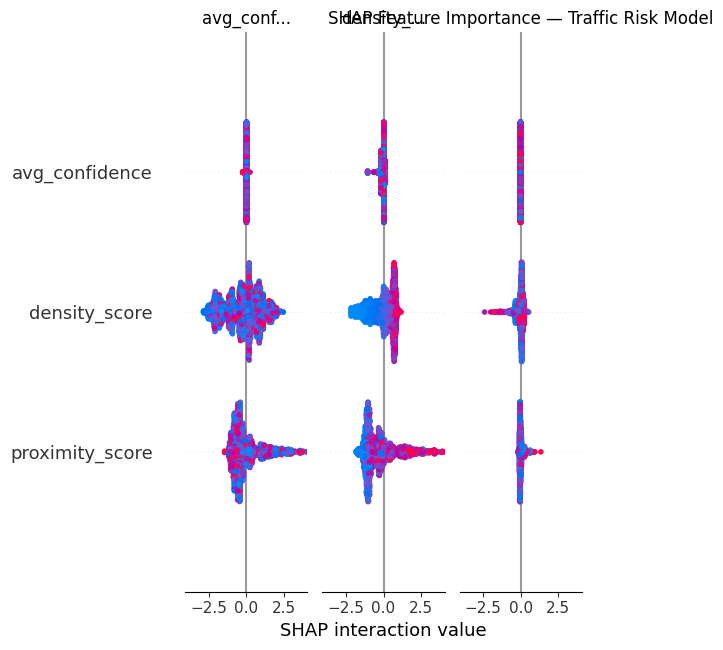

In [27]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, class_names=le.classes_, show=False)
plt.title("SHAP Feature Importance — Traffic Risk Model")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150)
plt.show()

In [28]:
# Cell 10 — Annotate a representative segment, not the full 30+ min video
MAX_FRAMES_TO_ANNOTATE = 4500  # ~2-3 min at 25-30fps

RISK_COLORS = {
    "normal": (0, 255, 0),
    "congested": (0, 165, 255),
    "high_risk": (0, 0, 255)
}

cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
out = cv2.VideoWriter("output_risk.mp4",
                      cv2.VideoWriter_fourcc(*"mp4v"),
                      fps, (img_w, img_h))

frame_idx = 0
while cap.isOpened() and frame_idx < MAX_FRAMES_TO_ANNOTATE:
    ret, frame = cap.read()
    if not ret:
        break

    feats = extract_frame_features(frame, model, img_area)
    feat_vec = pd.DataFrame([feats])[feature_cols]
    pred_enc = clf.predict(feat_vec)[0]
    pred_label = le.inverse_transform([pred_enc])[0]
    color = RISK_COLORS[pred_label]

    results = model(frame, conf=0.25, verbose=False)[0]
    annotated = results.plot()

    cv2.rectangle(annotated, (10, 10), (280, 55), color, -1)
    cv2.putText(annotated, f"Risk: {pred_label.upper()}", (15, 42),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)

    out.write(annotated)
    frame_idx += 1

cap.release()
out.release()
print(f"Done. Processed {frame_idx} frames -> output_risk.mp4")

Done. Processed 4500 frames -> output_risk.mp4


In [29]:
from google.colab import files
files.download("output_risk.mp4")
files.download("confusion_matrix.png")
files.download("shap_summary.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>